Welcome to Glucose Guide
This program helps calculate a suggested mealtime insulin dose.

Enter current blood glucose (mg/dL): 100
Enter target blood glucose (mg/dL): 75
Enter carbohydrates in meal (grams): 3
Enter insulin-to-carb ratio: 4
Enter insulin sensitivity factor: 2

Activity levels:
1. None
2. Light (walking, light jogging,  <30 min)
3. Moderate (weight lifting, running, 30-60 min)
4. Heavy (sports practice, intense training, >60 min)
Choose activity level over the next four hours (1-4): 1
Enter insulin pen increment (0.5 or 1): 1

--- Standard Guideline ---
Carb coverage dose: 0.75 units
Correction dose: 12.50 units
Base dose: 13.25 units
Activity level: None
Adjusted dose: 13.25 units
Suggested rounded dose: 13.00 units

--- Conservative Guideline ---
Carb coverage dose: 0.75 units
Correction dose: 10.00 units
Base dose: 10.75 units
Activity level: None
Adjusted dose: 10.75 units
Suggested rounded dose: 11.00 units

Difference between guidelines: 2.00 units

Would you like 

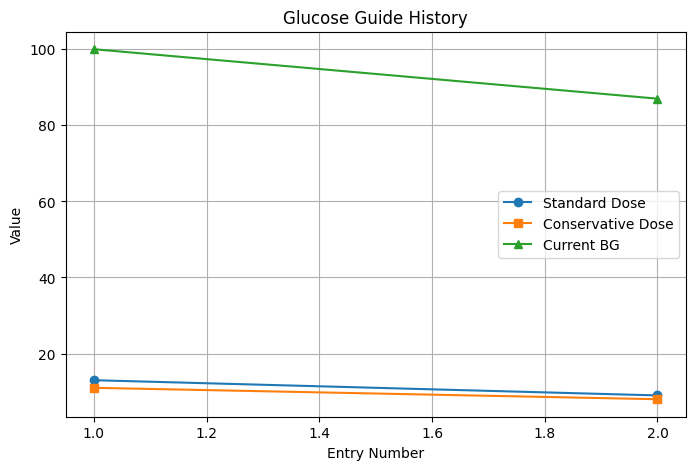


Thank you for using Glucose Guide.


In [1]:
# Glucose Guide program
# Calculates suggested mealtime insulin dose
# Includes carb coverage, correction dose, activity adjustment, safety checks,
# comparison of two dosing guidelines, and simple visualization

import matplotlib.pyplot as plt

history = []


def validate_inputs(current_bg, target_bg, carbs, icr, isf, pen_increment):
    if current_bg <= 0 or target_bg <= 0:
        return False
    if carbs < 0 or icr <= 0 or isf <= 0:
        return False
    if pen_increment not in [0.5, 1]:
        return False
    return True


def get_activity_factor(activity_choice):
    if activity_choice == "1":
        return 1.0, "None"
    elif activity_choice == "2":
        return 0.9, "Light"
    elif activity_choice == "3":
        return 0.8, "Moderate"
    elif activity_choice == "4":
        return 0.7, "Heavy"
    else:
        return 1.0, "None"


def standard_dose(current_bg, target_bg, carbs, icr, isf, activity_factor, pen_increment):
    carb_dose = carbs / icr
    correction_dose = (current_bg - target_bg) / isf

    if correction_dose < 0:
        correction_dose = 0

    base_dose = carb_dose + correction_dose
    adjusted_dose = base_dose * activity_factor
    rounded_dose = round(adjusted_dose / pen_increment) * pen_increment

    return carb_dose, correction_dose, base_dose, adjusted_dose, rounded_dose


def conservative_dose(current_bg, target_bg, carbs, icr, isf, activity_factor, pen_increment):
    # slightly more conservative option:
    # reduce correction dose by 20% before combining
    carb_dose = carbs / icr
    correction_dose = (current_bg - target_bg) / isf

    if correction_dose < 0:
        correction_dose = 0

    correction_dose = correction_dose * 0.8
    base_dose = carb_dose + correction_dose
    adjusted_dose = base_dose * activity_factor
    rounded_dose = round(adjusted_dose / pen_increment) * pen_increment

    return carb_dose, correction_dose, base_dose, adjusted_dose, rounded_dose


def print_safety_messages(current_bg, carbs, rounded_dose):
    if current_bg < 70:
        print("Warning: Blood glucose is below 70 mg/dL.")
        print("Treat low blood sugar first and recheck before taking insulin.\n")
    elif current_bg < 90:
        print("Caution: Blood glucose is on the low side.")

    if rounded_dose > 20:
        print("Caution: This is a high dose. Double-check all entries.")

    if carbs == 0:
        print("Note: No carbs entered. Dose is based only on correction if needed.")


def print_results(model_name, carb_dose, correction_dose, base_dose, adjusted_dose, rounded_dose, activity_label):
    print(f"\n--- {model_name} ---")
    print(f"Carb coverage dose: {carb_dose:.2f} units")
    print(f"Correction dose: {correction_dose:.2f} units")
    print(f"Base dose: {base_dose:.2f} units")
    print(f"Activity level: {activity_label}")
    print(f"Adjusted dose: {adjusted_dose:.2f} units")
    print(f"Suggested rounded dose: {rounded_dose:.2f} units")


def plot_history(history):
    if len(history) == 0:
        print("No history available to plot.")
        return

    entry_numbers = list(range(1, len(history) + 1))
    standard_doses = [entry["standard_dose"] for entry in history]
    conservative_doses = [entry["conservative_dose"] for entry in history]
    bg_values = [entry["current_bg"] for entry in history]

    plt.figure(figsize=(8, 5))
    plt.plot(entry_numbers, standard_doses, marker="o", label="Standard Dose")
    plt.plot(entry_numbers, conservative_doses, marker="s", label="Conservative Dose")
    plt.plot(entry_numbers, bg_values, marker="^", label="Current BG")
    plt.xlabel("Entry Number")
    plt.ylabel("Value")
    plt.title("Glucose Guide History")
    plt.legend()
    plt.grid(True)
    plt.show()


def print_summary(history):
    if len(history) == 0:
        print("No history available.")
        return

    standard_avg = sum(entry["standard_dose"] for entry in history) / len(history)
    conservative_avg = sum(entry["conservative_dose"] for entry in history) / len(history)
    avg_bg = sum(entry["current_bg"] for entry in history) / len(history)
    avg_carbs = sum(entry["carbs"] for entry in history) / len(history)

    print("\n--- Session Summary ---")
    print(f"Average current BG: {avg_bg:.2f} mg/dL")
    print(f"Average carbs: {avg_carbs:.2f} g")
    print(f"Average standard dose: {standard_avg:.2f} units")
    print(f"Average conservative dose: {conservative_avg:.2f} units")


print("Welcome to Glucose Guide")
print("This program helps calculate a suggested mealtime insulin dose.\n")

while True:
    current_bg = float(input("Enter current blood glucose (mg/dL): "))
    target_bg = float(input("Enter target blood glucose (mg/dL): "))
    carbs = float(input("Enter carbohydrates in meal (grams): "))
    icr = float(input("Enter insulin-to-carb ratio: "))
    isf = float(input("Enter insulin sensitivity factor: "))

    print("\nActivity levels:")
    print("1. None")
    print("2. Light (walking, light jogging,  <30 min)")
    print("3. Moderate (weight lifting, running, 30-60 min)")
    print("4. Heavy (sports practice, intense training, >60 min)")
    activity_choice = input("Choose activity level over the next four hours (1-4): ")

    pen_increment = float(input("Enter insulin pen increment (0.5 or 1): "))

    if not validate_inputs(current_bg, target_bg, carbs, icr, isf, pen_increment):
        print("Invalid input. Please enter realistic values.\n")
        continue

    if current_bg < 70:
        print("Warning: Blood glucose is below 70 mg/dL.")
        print("Treat low blood sugar by consuming 15g of glucose and recheck after 15 mintues.\n")
        again = input("Would you like to calculate another dose? (yes/no): ").lower()
        if again != "yes":
            break
        continue

    activity_factor, activity_label = get_activity_factor(activity_choice)

    # Standard guideline
    std_carb, std_corr, std_base, std_adjusted, std_rounded = standard_dose(
        current_bg, target_bg, carbs, icr, isf, activity_factor, pen_increment
    )

    # Conservative guideline
    con_carb, con_corr, con_base, con_adjusted, con_rounded = conservative_dose(
        current_bg, target_bg, carbs, icr, isf, activity_factor, pen_increment
    )

    print_safety_messages(current_bg, carbs, std_rounded)

    print_results("Standard Guideline", std_carb, std_corr, std_base, std_adjusted, std_rounded, activity_label)
    print_results("Conservative Guideline", con_carb, con_corr, con_base, con_adjusted, con_rounded, activity_label)

    difference = std_rounded - con_rounded
    print(f"\nDifference between guidelines: {difference:.2f} units")

    entry = {
        "current_bg": current_bg,
        "target_bg": target_bg,
        "carbs": carbs,
        "activity": activity_label,
        "standard_dose": std_rounded,
        "conservative_dose": con_rounded
    }
    history.append(entry)

    again = input("\nWould you like to calculate another dose? (yes/no): ").lower()
    if again != "yes":
        break

print("\nSession History:")
for i, entry in enumerate(history, start=1):
    print(
        f"{i}. BG: {entry['current_bg']} mg/dL, "
        f"Carbs: {entry['carbs']} g, "
        f"Activity: {entry['activity']}, "
        f"Standard Dose: {entry['standard_dose']:.2f} units, "
        f"Conservative Dose: {entry['conservative_dose']:.2f} units"
    )

print_summary(history)

plot_choice = input("\nWould you like to see a visualization of your history? (yes/no): ").lower()
if plot_choice == "yes":
    plot_history(history)

print("\nThank you for using Glucose Guide.")